In [1]:
# Ô lệnh do kaggle_run.sh chèn vào — đặt chế độ chạy trước khi notebook đọc biến này.
import os
os.environ['SMOKE_TEST'] = '0'
print('SMOKE_TEST =', os.environ['SMOKE_TEST'], '->', 'thử nhanh' if os.environ['SMOKE_TEST'] == '1' else 'chạy đầy đủ')


SMOKE_TEST = 0 -> chạy đầy đủ


# Lazada Uplift — 08 · 30 cột có thật sự không tệ hơn 69 cột?

Notebook 05 đã trả lời câu này một lần: Qini `0.02447` cho 30 cột so với `0.02566` cho 69 cột,
chênh `0.00119` — nhỏ hơn sàn nhiễu seed `0.0057`. Nhưng phép so đó có hai chỗ chấp:

1. **Tập 30 cột được chọn bằng thứ hạng đo trên `rct_select`**, rồi lại đem so trên chính
   `rct_select`. Lập luận vòng tròn, và thiên vị nghiêng về bản 30 cột.
2. **Bản 30 cột chạy bằng siêu tham số tinh chỉnh cho 69 cột**, tức nó bị chấp về tinh chỉnh.

Notebook 07 gỡ cả hai: nó dựng thứ hạng đặc trưng trên **Val** (tập chưa từng dùng để quyết
định gì về đặc trưng), và tinh chỉnh riêng DR-Learner trên tập 30 cột đó. Notebook này so
**bốn nhánh** để tách bạch xem chênh lệch đến từ đâu.

| Nhánh | Cột | Siêu tham số | Vai trò |
|---|---|---|---|
| **A** | 69 | 69 cột | mốc so sánh |
| **B** | 30 (hạng `rct_select`) | 69 cột | nối lại với con số cũ của notebook 05 |
| **C** | 30 (hạng **Val**) | 69 cột | tách riêng ảnh hưởng của *nguồn xếp hạng* |
| **D** | 30 (hạng **Val**) | **30 cột** | **nhánh ứng viên bàn giao** |

**Không nạp `rct_holdout.parquet`.** Bản 30 cột, nếu được đem bàn giao, sẽ đi kèm giới hạn
được ghi rõ: nó chưa từng được đo trên tập giữ cuối.

# Phần 1 — Thiết lập

### Bước 1 — Thư viện và đường dẫn

In [2]:
import os
import json
import time
import glob
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

import warnings
warnings.filterwarnings('ignore')

IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    _train_files = glob.glob('/kaggle/input/**/train.parquet', recursive=True)
    if not _train_files:
        raise FileNotFoundError(
            'Không tìm thấy train.parquet trong /kaggle/input. Kiểm tra dataset source.')
    ROOT = '/kaggle/working'
    DATA_DIR = os.path.dirname(_train_files[0])
    ART_DIR = '/kaggle/working/artifacts'
    FIG_DIR = '/kaggle/working/reports/figures'
else:
    ROOT = '..' if os.path.basename(os.getcwd()) == 'notebooks' else '.'
    DATA_DIR = os.path.join(ROOT, 'dataset')
    ART_DIR = os.path.join(ROOT, 'artifacts')
    FIG_DIR = os.path.join(ROOT, 'reports', 'figures')

os.makedirs(ART_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)


def tim_file(ten):
    '''Tìm artifact local hoặc trong output của kernel nguồn trên Kaggle.'''
    ung_vien = [os.path.join(ART_DIR, ten)]
    if IS_KAGGLE:
        ung_vien += sorted(glob.glob(f'/kaggle/input/**/{ten}', recursive=True))
    ung_vien = [p for p in ung_vien if os.path.exists(p)]
    if not ung_vien:
        raise FileNotFoundError(
            f'Không tìm thấy {ten}. Chạy notebook 07 trước, hoặc kiểm tra kernel_sources.')
    if len(ung_vien) > 1:
        print(f'!!! Có {len(ung_vien)} bản {ten}; đang dùng: {ung_vien[0]}')
    return ung_vien[0]


SEED = 42
TRAPZ = getattr(np, 'trapezoid', None) or np.trapz

plt.style.use('seaborn-v0_8-whitegrid')

# Kaggle không có font phủ dấu tiếng Việt nên tiêu đề biểu đồ ra ô vuông (xem figure 20 và 21
# của các lần chạy trước). DejaVu Sans đi kèm chính matplotlib nên máy nào cũng có, và nó phủ đủ.
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans'] + plt.rcParams['font.sans-serif']

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print('Môi trường :', 'Kaggle' if IS_KAGGLE else 'Local')
print('DATA_DIR   :', DATA_DIR)
print('ART_DIR    :', ART_DIR)
print('rct_holdout: KHÔNG nạp')

Môi trường : Kaggle
DATA_DIR   : /kaggle/input/datasets/hatrungkienhatuki/lazada-uplift-data
ART_DIR    : /kaggle/working/artifacts
rct_holdout: KHÔNG nạp


### Bước 2 — Chế độ chạy

In [3]:
SMOKE_TEST = os.environ.get('SMOKE_TEST', '1').lower() not in ('0', 'false', 'no')

if SMOKE_TEST:
    SEEDS = [42, 1]
    N_FIT = 50_000
    N_BOOT = 100
else:
    SEEDS = [42, 1, 7, 13, 23]      # cùng bộ seed với notebook 05, để số nối được với nhau
    N_FIT = 200_000                 # cùng cỡ mẫu với notebook 05
    N_BOOT = 1_000

RUN_MODE = 'smoke_test' if SMOKE_TEST else 'full'

print('=' * 70)
print(f'  08 — SO 30 CỘT VỚI 69 CỘT   |   CHẾ ĐỘ: {RUN_MODE.upper()}')
print(f'  Số nhánh          : 4')
print(f'  Số seed mỗi nhánh : {len(SEEDS)}  -> tổng {4*len(SEEDS)} lần huấn luyện')
print(f'  Cỡ mẫu mỗi lần    : {N_FIT:,} dòng')
print(f'  Bootstrap theo cặp: {N_BOOT:,} lần')
if SMOKE_TEST:
    print('  >>> CHỈ ĐỂ KIỂM TRA CODE, KHÔNG DÙNG BÁO CÁO <<<')
print('=' * 70)

  08 — SO 30 CỘT VỚI 69 CỘT   |   CHẾ ĐỘ: FULL
  Số nhánh          : 4
  Số seed mỗi nhánh : 5  -> tổng 20 lần huấn luyện
  Cỡ mẫu mỗi lần    : 200,000 dòng
  Bootstrap theo cặp: 1,000 lần


### Bước 3 — Nạp dữ liệu và các quyết định đã chốt

In [4]:
tuning69 = json.load(open(tim_file('best_params.json'), encoding='utf-8'))
P_DR69 = tuning69['best_params']['DRLearner']['params']
E_ALPHA = float(tuning69['xu_ly_overlap']['propensity_alpha'])
E_CLIP = (E_ALPHA, 1 - E_ALPHA)

tuning30 = json.load(open(tim_file('best_params_k30.json'), encoding='utf-8'))
P_DR30 = tuning30['best_params']['DRLearner']['params']

xh_val = json.load(open(tim_file('xep_hang_val.json'), encoding='utf-8'))
TOP_K_VAL = xh_val['dac_trung_o_muc_chot']
SO_COT_TRUNG = xh_val['doi_chieu_voi_04b']['so_cot_trung_o_top_k']
RHO_HAI_HANG = xh_val['doi_chieu_voi_04b']['tuong_quan_hang_spearman']

quet = json.load(open(tim_file('quet_dac_trung.json'), encoding='utf-8'))
TOP_K_SELECT = quet['dac_trung_o_muc_chot']
SAN_NHIEU_NB05 = quet['san_nhieu']

finfo = json.load(open(tim_file('feature_info.json'), encoding='utf-8'))
FEATS = finfo['tat_ca_dac_trung']
N_FEAT = len(FEATS)
K_CHOT = len(TOP_K_VAL)

train = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
val = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))
rct_sel = pd.read_parquet(os.path.join(DATA_DIR, 'rct_select.parquet'))
full = pd.concat([train, val], ignore_index=True)

X_full = full[FEATS].values.astype(np.float32)
W_full, Y_full = full['is_treat'].values, full['label'].values
X_sel = rct_sel[FEATS].values.astype(np.float32)
y_sel, w_sel = rct_sel['label'].values, rct_sel['is_treat'].values

# Chốt cổng
assert N_FEAT == 69 and not any(f.startswith('fe_') for f in FEATS)
assert len(TOP_K_SELECT) == len(TOP_K_VAL) == K_CHOT
assert set(TOP_K_VAL).issubset(FEATS) and set(TOP_K_SELECT).issubset(FEATS)
assert tuning30['cau_hinh']['feature_names'] == TOP_K_VAL, \
    'best_params_k30.json tinh chỉnh trên tập cột khác với xep_hang_val.json — chạy lại notebook 07'
if tuning30['run_mode'] != RUN_MODE:
    print(f'!!! best_params_k30.json là kết quả {tuning30["run_mode"]!r} '
          f'nhưng notebook này đang chạy {RUN_MODE!r} — số sẽ khập khiễng.')

HAI_TAP_TRUNG_NHAU = TOP_K_VAL == TOP_K_SELECT

print(f'Train + Val   : {len(full):>8,} dòng')
print(f'rct_select    : {len(rct_sel):>8,} dòng')
print(f'rct_holdout   : KHÔNG nạp')
print()
print(f'k chốt              : {K_CHOT}')
print(f'Trùng nhau hai hạng : {SO_COT_TRUNG}/{K_CHOT} cột | Spearman {RHO_HAI_HANG:+.3f}')
print(f'Sàn nhiễu notebook05: ±{SAN_NHIEU_NB05}')
print()
print(f'hparam 69 cột: {P_DR69}')
print(f'hparam {K_CHOT} cột: {P_DR30}')
if HAI_TAP_TRUNG_NHAU:
    print('\n!!! Hai tập k cột GIỐNG HỆT nhau -> nhánh B và C sẽ cho cùng kết quả.')

Train + Val   :  926,669 dòng
rct_select    :   90,834 dòng
rct_holdout   : KHÔNG nạp

k chốt              : 30
Trùng nhau hai hạng : 21/30 cột | Spearman +0.377
Sàn nhiễu notebook05: ±0.0057

hparam 69 cột: {'n_estimators': 200, 'learning_rate': 0.04141536110538596, 'max_depth': 5, 'min_child_samples': 38}
hparam 30 cột: {'n_estimators': 300, 'learning_rate': 0.01459007452373112, 'max_depth': 4, 'min_child_samples': 46}


# Phần 2 — Cổng quyết định

**Viết ở đây, trước khi bất kỳ con số nào được tính.** Ô lệnh dưới băm định nghĩa cổng lại
thành một mã; Bước 13 băm lần nữa và dừng nếu khác. Cùng cách làm với `decisions_locked.json`
của notebook 04b: ranh giới giữa "chọn" và "đo" phải kiểm được bằng máy, không phải là một
lời hứa trong markdown.

Phát biểu tối đa được phép rút ra là **"không tệ hơn"**. Không bao giờ là "tốt hơn" — chênh
lệch nằm dưới sàn nhiễu thì không quy được cho việc bớt cột.

**Hai thang nhiễu, đừng trộn vào nhau.** `san_nhieu` đo dao động khi chỉ **đổi seed** (cỡ
`±0,006`). KTC bootstrap đo dao động khi **lấy mẫu lại dòng** của `rct_select` (rộng cỡ
`±0,02`). Chúng lệch nhau cả bậc độ lớn, nên điều kiện 2 (đo trên thang seed) và điều kiện 3
(đo trên thang bootstrap) phải dùng hai mốc khác nhau. Đòi cận dưới bootstrap vượt
`−san_nhieu` là đòi một phép kiểm mà `rct_select` không đủ công suất để qua — kể cả khi bản
30 cột thật sự tốt hơn. Điều kiện 3 vì thế phát biểu ở dạng yếu hơn nhưng đúng: *dữ liệu
không chứng minh được D tệ hơn A*, kèm theo con số **biên độ chặt nhất chứng nhận được**
để báo cáo nói thật về giới hạn của mình.

### Bước 4 — Khóa ba điều kiện

In [5]:
CONG = {
    'nhanh_moc': 'A',
    'nhanh_ung_vien': 'D',
    'dieu_kien_1': {
        'mo_ta': 'Hai thứ hạng độc lập phải đồng ý về tập k cột',
        'quy_tac': 'so_cot_trung_o_top_k >= nguong',
        'nguong': 20,
    },
    'dieu_kien_2': {
        'mo_ta': 'Nhánh ứng viên không tụt quá sàn nhiễu so với mốc',
        'quy_tac': 'Qini_TB(D) >= Qini_TB(A) - san_nhieu',
    },
    'dieu_kien_3': {
        'mo_ta': 'Bootstrap theo cặp trên rct_select không CHỨNG MINH được D tệ hơn A',
        'quy_tac': 'can_tren_KTC_95(Qini(D) - Qini(A)) >= 0',
        'vi_sao_khong_so_voi_san_nhieu': (
            'KTC bootstrap đo dao động do LẤY MẪU DÒNG trên rct_select (rộng cỡ ±0,02), '
            'còn san_nhieu đo dao động do ĐỔI SEED (cỡ ±0,006). Hai thang lệch nhau cả bậc '
            'độ lớn. Đòi cận dưới bootstrap vượt -san_nhieu là đòi một phép kiểm mà bộ dữ '
            'liệu này không đủ công suất để qua, KỂ CẢ KHI D thật sự tốt hơn A — nên nó đo '
            'công suất của tập dữ liệu chứ không đo chất lượng của bản 30 cột.'),
        'bao_cao_kem': ('bien_do_chung_minh_duoc = -can_duoi_KTC_95 — biên độ "không kém hơn" '
                        'chặt nhất mà bộ dữ liệu này chứng nhận được. Phải ghi vào báo cáo '
                        'thay vì giả vờ chứng nhận được một biên độ chặt hơn.'),
    },
    'phat_bieu_toi_da': 'khong te hon (KHONG duoc phat bieu la tot hon)',
    'he_qua_neu_dat': ('Được phép dựng notebook 09 để xuất bản 30 cột song song. '
                       'Việc ĐÈ artifact bàn giao vẫn là một bước riêng, xin phép riêng.'),
    'he_qua_neu_khong_dat': 'Giữ nguyên bản 69 cột. Ghi kết quả vào báo cáo như một phát hiện âm.',
}

MA_BAM_CONG = hashlib.sha256(
    json.dumps(CONG, sort_keys=True, ensure_ascii=False).encode('utf-8')).hexdigest()[:16]

print('CỔNG QUYẾT ĐỊNH — khóa lúc này, trước khi có bất kỳ con số nào')
print('=' * 70)
for k in ('dieu_kien_1', 'dieu_kien_2', 'dieu_kien_3'):
    print(f'  {k}: {CONG[k]["mo_ta"]}')
    print(f'      {CONG[k]["quy_tac"]}'
          + (f'   (ngưỡng = {CONG[k]["nguong"]})' if 'nguong' in CONG[k] else ''))
print('=' * 70)
print('Mã băm cổng:', MA_BAM_CONG)

CỔNG QUYẾT ĐỊNH — khóa lúc này, trước khi có bất kỳ con số nào
  dieu_kien_1: Hai thứ hạng độc lập phải đồng ý về tập k cột
      so_cot_trung_o_top_k >= nguong   (ngưỡng = 20)
  dieu_kien_2: Nhánh ứng viên không tụt quá sàn nhiễu so với mốc
      Qini_TB(D) >= Qini_TB(A) - san_nhieu
  dieu_kien_3: Bootstrap theo cặp trên rct_select không CHỨNG MINH được D tệ hơn A
      can_tren_KTC_95(Qini(D) - Qini(A)) >= 0
Mã băm cổng: a4f5c2ff6ae084f6


# Phần 3 — Dựng phép đo

### Bước 5 — Mẫu dòng cố định

Cùng seed, cùng cách phân tầng, cùng cỡ mẫu với notebook 05 — để con số của nhánh A và nhánh B
nối được với bảng cũ. Mọi nhánh dùng **đúng một mẫu dòng**, nên chênh lệch giữa các nhánh chỉ
đến từ tập cột và siêu tham số.

In [6]:
rng_mau = np.random.RandomState(SEED)
strata = W_full * 2 + Y_full
_idx = []
for s in np.unique(strata):
    pos = np.where(strata == s)[0]
    n = max(1, int(round(N_FIT * len(pos) / len(full))))
    _idx.append(rng_mau.choice(pos, size=min(n, len(pos)), replace=False))
IDX = np.sort(np.concatenate(_idx))

print(f'Mẫu cố định: {len(IDX):,} dòng | treat {W_full[IDX].mean()*100:.2f}% '
      f'| mua {Y_full[IDX].mean()*100:.2f}%')
print(f'(toàn tập  : {len(full):,} dòng | treat {W_full.mean()*100:.2f}% '
      f'| mua {Y_full.mean()*100:.2f}%)')

Mẫu cố định: 200,000 dòng | treat 22.17% | mua 1.99%
(toàn tập  : 926,669 dòng | treat 22.17% | mua 1.99%)


### Bước 6 — DR-Learner và hệ số Qini

Bản sao từ notebook 05, chỉ khác một chỗ: siêu tham số của tầng cuối giờ là **tham số truyền
vào**, vì bốn nhánh dùng hai bộ khác nhau. Ba mô hình phụ vẫn giữ nguyên tham số cố định ở mọi
nhánh — nếu chúng cũng đổi theo thì không tách được ảnh hưởng của tầng cuối.

In [7]:
def fit_drlearner(X, W, Y, seed, params, n_folds=5):
    n = len(X)
    e_hat, mu0, mu1 = np.zeros(n), np.zeros(n), np.zeros(n)
    par = dict(n_estimators=200, learning_rate=0.05, max_depth=5,
               min_child_samples=50, random_state=seed, verbose=-1)

    for tr, te in StratifiedKFold(n_folds, shuffle=True, random_state=seed).split(X, W * 2 + Y):
        e_hat[te] = np.clip(
            lgb.LGBMClassifier(**par).fit(X[tr], W[tr]).predict_proba(X[te])[:, 1], *E_CLIP)
        mu0[te] = lgb.LGBMClassifier(**par).fit(
            X[tr][W[tr] == 0], Y[tr][W[tr] == 0]).predict_proba(X[te])[:, 1]
        mu1[te] = lgb.LGBMClassifier(**par).fit(
            X[tr][W[tr] == 1], Y[tr][W[tr] == 1]).predict_proba(X[te])[:, 1]

    dr = (mu1 - mu0) + W * (Y - mu1) / e_hat - (1 - W) * (Y - mu0) / (1 - e_hat)
    return lgb.LGBMRegressor(**params, random_state=seed, verbose=-1).fit(X, dr)


def _sap_xep(y, w, score, seed=SEED):
    rng = np.random.RandomState(seed)
    order = np.lexsort((rng.rand(len(y)), -np.asarray(score, dtype=float)))
    y_, w_ = np.asarray(y)[order], np.asarray(w)[order]
    return np.cumsum(w_), np.cumsum(1 - w_), np.cumsum(y_ * w_), np.cumsum(y_ * (1 - w_))


def qini_tho(y, w, score):
    nt, nc, yt, yc = _sap_xep(y, w, score)
    n = len(y)
    g = (yt - yc * np.divide(nt, nc, out=np.zeros(n), where=nc > 0)) / n
    return float(TRAPZ(g, np.arange(1, n + 1) / n) - 0.5 * g[-1])


def qini_tran(y, w):
    '''Trần chuẩn hóa: hệ số Qini của xếp hạng biết trước. Chỉ phụ thuộc (y, w).'''
    oracle = np.where(np.asarray(w) == 1, y, -np.asarray(y)).astype(float)
    return qini_tho(y, w, oracle)


def qini_score(y, w, score, tran=None):
    tran = qini_tran(y, w) if tran is None else tran
    return qini_tho(y, w, score) / tran if tran > 0 else np.nan


print('Đã định nghĩa fit_drlearner, qini_score')

Đã định nghĩa fit_drlearner, qini_score


### Bước 7 — Bốn nhánh

In [8]:
NHANH = {
    'A': {'nhan': f'{N_FEAT} cột · hparam {N_FEAT}', 'cot': FEATS, 'params': P_DR69,
          'nguon_hang': '—', 'vai_tro': 'mốc so sánh'},
    'B': {'nhan': f'{K_CHOT} cột (hạng rct_select) · hparam {N_FEAT}', 'cot': TOP_K_SELECT,
          'params': P_DR69, 'nguon_hang': 'rct_select (04b)',
          'vai_tro': 'nối lại với notebook 05'},
    'C': {'nhan': f'{K_CHOT} cột (hạng Val) · hparam {N_FEAT}', 'cot': TOP_K_VAL,
          'params': P_DR69, 'nguon_hang': 'Val (07)',
          'vai_tro': 'tách riêng ảnh hưởng của nguồn xếp hạng'},
    'D': {'nhan': f'{K_CHOT} cột (hạng Val) · hparam {K_CHOT}', 'cot': TOP_K_VAL,
          'params': P_DR30, 'nguon_hang': 'Val (07)',
          'vai_tro': 'ỨNG VIÊN BÀN GIAO'},
}

for ma, cfg in NHANH.items():
    cfg['ik'] = [i for i, f in enumerate(FEATS) if f in set(cfg['cot'])]
    assert len(cfg['ik']) == len(cfg['cot'])

display(pd.DataFrame([
    {'Nhánh': ma, 'Mô tả': c['nhan'], 'Số cột': len(c['cot']),
     'Nguồn xếp hạng': c['nguon_hang'], 'Vai trò': c['vai_tro']}
    for ma, c in NHANH.items()]))

,Nhánh,Mô tả,Số cột,Nguồn xếp hạng,Vai trò
0,A,69 cột · hparam 69,69,—,mốc so sánh
1,B,30 cột (hạng rct_select) · hparam 69,30,rct_select (04b),nối lại với notebook 05
2,C,30 cột (hạng Val) · hparam 69,30,Val (07),tách riêng ảnh hưởng của nguồn xếp hạng
3,D,30 cột (hạng Val) · hparam 30,30,Val (07),ỨNG VIÊN BÀN GIAO


# Phần 4 — Chạy

### Bước 8 — Mỗi nhánh, huấn luyện lại với từng seed

Điểm CATE của từng seed được giữ lại để Bước 11 lấy trung bình. Trung bình nhiều seed là điểm
số dùng cho bootstrap theo cặp: nó khử phần dao động do seed, để phép so chỉ còn nói về tập cột
và siêu tham số.

In [9]:
ket_qua = []
diem = {}                      # mã nhánh -> điểm CATE trung bình 5 seed trên rct_select
TRAN_SEL = qini_tran(y_sel, w_sel)
t_bat_dau = time.time()

for ma, cfg in NHANH.items():
    ik = cfg['ik']
    Xk = X_full[np.ix_(IDX, ik)]
    Xs = X_sel[:, ik]
    qs, cates = [], []
    for sd in SEEDS:
        m = fit_drlearner(Xk, W_full[IDX], Y_full[IDX], sd, cfg['params'])
        c = m.predict(Xs)
        cates.append(c)
        qs.append(qini_score(y_sel, w_sel, c, TRAN_SEL))
    diem[ma] = np.mean(cates, axis=0)
    ket_qua.append({
        'nhanh': ma, 'nhan': cfg['nhan'], 'so_cot': len(ik),
        'Qini_TB': float(np.mean(qs)), 'sd_seed': float(np.std(qs)),
        'thap_nhat': float(min(qs)), 'cao_nhat': float(max(qs)),
        'Qini_diem_TB_seed': float(qini_score(y_sel, w_sel, diem[ma], TRAN_SEL)),
        'qini_tung_seed': [float(q) for q in qs],
    })
    print(f'  {ma} | {cfg["nhan"]:<42} | TB {np.mean(qs):+.4f} '
          f'| sd {np.std(qs):.4f} | [{min(qs):+.4f} .. {max(qs):+.4f}] '
          f'| {time.time()-t_bat_dau:.0f}s', flush=True)

df = pd.DataFrame(ket_qua)
print(f'\nXong sau {(time.time()-t_bat_dau)/60:.1f} phút.')

  A | 69 cột · hparam 69                         | TB +0.0257 | sd 0.0040 | [+0.0210 .. +0.0308] | 173s
  B | 30 cột (hạng rct_select) · hparam 69       | TB +0.0245 | sd 0.0057 | [+0.0174 .. +0.0324] | 311s
  C | 30 cột (hạng Val) · hparam 69              | TB +0.0192 | sd 0.0020 | [+0.0167 .. +0.0220] | 443s
  D | 30 cột (hạng Val) · hparam 30              | TB +0.0253 | sd 0.0060 | [+0.0182 .. +0.0351] | 578s

Xong sau 9.6 phút.


### Bước 9 — Sàn nhiễu: phép đo này phân giải được tới đâu

Cùng định nghĩa với notebook 05 — trung bình độ lệch chuẩn giữa các seed. Mọi chênh lệch nhỏ
hơn con số này **không quy được** cho tập cột hay siêu tham số.

In [10]:
san_nhieu = float(df['sd_seed'].mean())
se_tb = san_nhieu / np.sqrt(len(SEEDS))

Q_MOC = float(df.loc[df.nhanh == CONG['nhanh_moc'], 'Qini_TB'].iloc[0])
Q_UV = float(df.loc[df.nhanh == CONG['nhanh_ung_vien'], 'Qini_TB'].iloc[0])

print(f'Dao động Qini khi chỉ đổi seed (trung bình 4 nhánh): ±{san_nhieu:.4f}')
print(f'Sai số chuẩn của trung bình {len(SEEDS)} seed             : ±{se_tb:.4f}')
print(f'(sàn nhiễu notebook 05, để đối chiếu)               : ±{SAN_NHIEU_NB05:.4f}')
print()
print(f'Nhánh mốc      A: {Q_MOC:+.5f}')
print(f'Nhánh ứng viên D: {Q_UV:+.5f}')
print(f'Hiệu D − A      : {Q_UV - Q_MOC:+.5f}  '
      f'({"trong" if abs(Q_UV - Q_MOC) <= san_nhieu else "NGOÀI"} sàn nhiễu)')

Dao động Qini khi chỉ đổi seed (trung bình 4 nhánh): ±0.0044
Sai số chuẩn của trung bình 5 seed             : ±0.0020
(sàn nhiễu notebook 05, để đối chiếu)               : ±0.0057

Nhánh mốc      A: +0.02566
Nhánh ứng viên D: +0.02529
Hiệu D − A      : -0.00037  (trong sàn nhiễu)


# Phần 5 — Kết quả

### Bước 10 — Bảng đầy đủ

In [11]:
hien = df[['nhanh', 'nhan', 'so_cot', 'Qini_TB', 'sd_seed', 'thap_nhat', 'cao_nhat',
           'Qini_diem_TB_seed']].copy()
hien['lech_so_voi_A'] = hien['Qini_TB'] - Q_MOC
hien['trong_san_nhieu'] = hien['lech_so_voi_A'].abs() <= san_nhieu
display(hien.round(5))

print('Đọc bảng:')
print(f'  · Qini_TB          — trung bình {len(SEEDS)} seed, mỗi seed là một lần huấn luyện lại.')
print('  · Qini_diem_TB_seed — Qini của điểm CATE lấy trung bình các seed (dùng cho bootstrap).')
print(f'  · trong_san_nhieu  — chênh lệch so với A có nhỏ hơn ±{san_nhieu:.4f} không.')
if HAI_TAP_TRUNG_NHAU:
    print('\n  · B và C trùng nhau vì hai thứ hạng cho ra cùng một tập cột.')

,nhanh,nhan,so_cot,Qini_TB,sd_seed,thap_nhat,cao_nhat,Qini_diem_TB_seed,lech_so_voi_A,trong_san_nhieu
0,A,69 cột · hparam 69,69,0.02566,0.00399,0.02103,0.03075,0.02611,0.00000,True
1,B,30 cột (hạng rct_select) · hparam 69,30,0.02447,0.00573,0.01739,0.03245,0.02372,-0.00119,True
2,C,30 cột (hạng Val) · hparam 69,30,0.01916,0.00200,0.01668,0.02205,0.01843,-0.00651,False
3,D,30 cột (hạng Val) · hparam 30,30,0.02529,0.00597,0.01823,0.03506,0.02099,-0.00037,True


Đọc bảng:
  · Qini_TB          — trung bình 5 seed, mỗi seed là một lần huấn luyện lại.
  · Qini_diem_TB_seed — Qini của điểm CATE lấy trung bình các seed (dùng cho bootstrap).
  · trong_san_nhieu  — chênh lệch so với A có nhỏ hơn ±0.0044 không.


### Bước 11 — Bootstrap theo cặp trên `rct_select`

Lấy lại **cùng một bộ dòng** cho cả hai nhánh ở mỗi vòng bootstrap, rồi mới trừ. Cách này khử
phần dao động chung do lấy mẫu — thứ tác động lên hai nhánh như nhau — nên KTC của *hiệu* hẹp
hơn nhiều so với việc trừ hai KTC riêng lẻ. Đúng quy tắc tuyên bố đã dùng ở notebook 03 và 04b.

In [12]:
rng_boot = np.random.RandomState(SEED)
n_sel = len(y_sel)
ma_moc, ma_uv = CONG['nhanh_moc'], CONG['nhanh_ung_vien']
s_moc, s_uv = diem[ma_moc], diem[ma_uv]

hieu_b, q_moc_b, q_uv_b = [], [], []
t0 = time.time()

for b in range(N_BOOT):
    idx = rng_boot.randint(0, n_sel, n_sel)
    yb, wb = y_sel[idx], w_sel[idx]
    tran = qini_tran(yb, wb)
    if not tran > 0:
        continue
    qa = qini_tho(yb, wb, s_moc[idx]) / tran
    qd = qini_tho(yb, wb, s_uv[idx]) / tran
    q_moc_b.append(qa)
    q_uv_b.append(qd)
    hieu_b.append(qd - qa)
    if (b + 1) % max(1, N_BOOT // 5) == 0:
        print(f'  {b+1:>5}/{N_BOOT} | {time.time()-t0:.0f}s', flush=True)

hieu_b = np.array(hieu_b)
HIEU_LO, HIEU_HI = np.percentile(hieu_b, [2.5, 97.5])
HIEU_TB = float(hieu_b.mean())
MOC_LO, MOC_HI = np.percentile(q_moc_b, [2.5, 97.5])
UV_LO, UV_HI = np.percentile(q_uv_b, [2.5, 97.5])

print()
display(pd.DataFrame([
    {'Nhánh': ma_moc, 'Mô tả': NHANH[ma_moc]['nhan'], 'Qini': np.mean(q_moc_b),
     'KTC thấp': MOC_LO, 'KTC cao': MOC_HI},
    {'Nhánh': ma_uv, 'Mô tả': NHANH[ma_uv]['nhan'], 'Qini': np.mean(q_uv_b),
     'KTC thấp': UV_LO, 'KTC cao': UV_HI},
]).round(5))

print(f'Hiệu ({ma_uv} − {ma_moc}) : {HIEU_TB:+.5f}  '
      f'| KTC 95% [{HIEU_LO:+.5f} ; {HIEU_HI:+.5f}]  ({len(hieu_b)} vòng dùng được)')
print(f'KTC của hiệu {"KHÔNG chứa" if HIEU_LO * HIEU_HI > 0 else "CHỨA"} 0')
print()
print(f'Bề rộng KTC bootstrap (lấy mẫu dòng) : {HIEU_HI - HIEU_LO:.5f}')
print(f'Sàn nhiễu seed (đổi seed)            : {2*san_nhieu:.5f}  (±{san_nhieu:.5f})')
print(f'  -> bootstrap rộng gấp {(HIEU_HI - HIEU_LO)/(2*san_nhieu):.0f} lần sàn nhiễu seed.')
print('  Hai thang này KHÁC NHAU: một cái do lấy mẫu dòng, một cái do đổi seed.')
print('  Không được đem cận dưới bootstrap so với sàn nhiễu seed.')

    200/1000 | 12s
    400/1000 | 25s
    600/1000 | 37s
    800/1000 | 49s
   1000/1000 | 62s



,Nhánh,Mô tả,Qini,KTC thấp,KTC cao
0,A,69 cột · hparam 69,0.02629,0.00217,0.05189
1,D,30 cột (hạng Val) · hparam 30,0.02140,-0.00285,0.04592


Hiệu (D − A) : -0.00489  | KTC 95% [-0.02669 ; +0.01740]  (1000 vòng dùng được)
KTC của hiệu CHỨA 0

Bề rộng KTC bootstrap (lấy mẫu dòng) : 0.04409
Sàn nhiễu seed (đổi seed)            : 0.00884  (±0.00442)
  -> bootstrap rộng gấp 5 lần sàn nhiễu seed.
  Hai thang này KHÁC NHAU: một cái do lấy mẫu dòng, một cái do đổi seed.
  Không được đem cận dưới bootstrap so với sàn nhiễu seed.


### Bước 12 — Biểu đồ

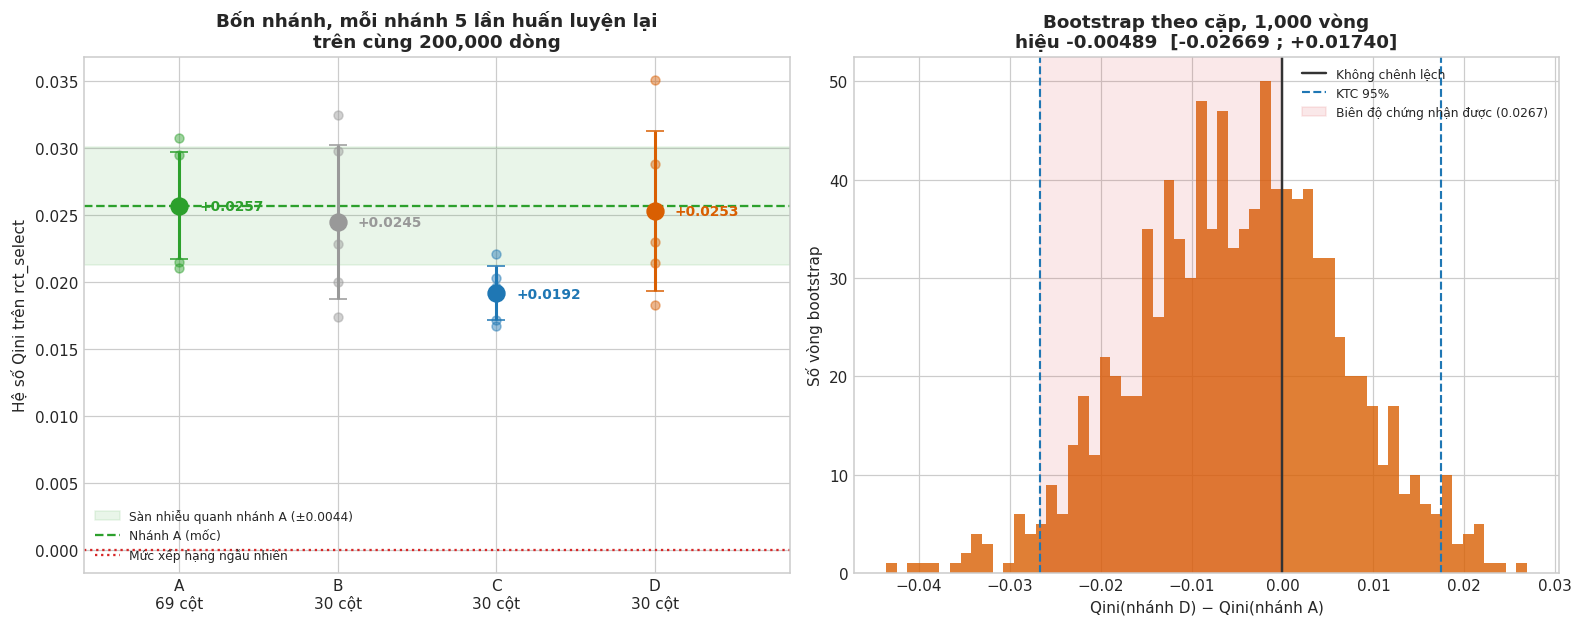

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8))

# --- trái: bốn nhánh, từng seed một -----------------------------------------
ax = axes[0]
mau_nhanh = {'A': '#2ca02c', 'B': '#999999', 'C': '#1f77b4', 'D': '#d95f02'}
xs = np.arange(len(df))

ax.axhspan(Q_MOC - san_nhieu, Q_MOC + san_nhieu, color='#2ca02c', alpha=0.10,
           label=f'Sàn nhiễu quanh nhánh A (±{san_nhieu:.4f})')
ax.axhline(Q_MOC, color='#2ca02c', ls='--', lw=1.5, label='Nhánh A (mốc)')
ax.axhline(0, color='#d62728', ls=':', lw=1.5, label='Mức xếp hạng ngẫu nhiên')

for i, r in df.iterrows():
    c = mau_nhanh[r['nhanh']]
    ax.scatter([i] * len(r['qini_tung_seed']), r['qini_tung_seed'],
               color=c, s=34, alpha=0.45, zorder=3)
    ax.errorbar(i, r['Qini_TB'], yerr=r['sd_seed'], fmt='o', color=c, ms=11,
                capsize=6, lw=2, zorder=4)
    ax.annotate(f"{r['Qini_TB']:+.4f}", (i, r['Qini_TB']), textcoords='offset points',
                xytext=(13, -3), fontsize=9, color=c, fontweight='bold')

ax.set_xticks(xs)
ax.set_xticklabels([f"{r['nhanh']}\n{r['so_cot']} cột" for _, r in df.iterrows()])
ax.set_xlim(-0.6, len(df) - 0.15)
ax.set_ylabel('Hệ số Qini trên rct_select')
ax.set_title(f'Bốn nhánh, mỗi nhánh {len(SEEDS)} lần huấn luyện lại\n'
             f'trên cùng {len(IDX):,} dòng')
ax.legend(fontsize=8, loc='lower left')

# --- phải: phân phối bootstrap của hiệu --------------------------------------
ax = axes[1]
ax.hist(hieu_b, bins=60, color='#d95f02', alpha=0.8)
ax.axvline(0, color='#333333', lw=1.6, label='Không chênh lệch')
ax.axvline(HIEU_LO, color='#1f77b4', ls='--', lw=1.4, label='KTC 95%')
ax.axvline(HIEU_HI, color='#1f77b4', ls='--', lw=1.4)
ax.axvspan(HIEU_LO, 0, color='#d62728', alpha=0.10,
           label=f'Biên độ chứng nhận được ({-HIEU_LO:.4f})')
ax.set_xlabel(f'Qini(nhánh {ma_uv}) − Qini(nhánh {ma_moc})')
ax.set_ylabel('Số vòng bootstrap')
ax.set_title(f'Bootstrap theo cặp, {len(hieu_b):,} vòng\n'
             f'hiệu {HIEU_TB:+.5f}  [{HIEU_LO:+.5f} ; {HIEU_HI:+.5f}]')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '28_so_sanh_k30.png'), bbox_inches='tight')
plt.show()

# Phần 6 — Cổng quyết định

### Bước 13 — Chấm ba điều kiện

Băm lại định nghĩa cổng và so với mã băm chốt ở Bước 4. Nếu ai đó sửa cổng sau khi đã nhìn
thấy số, ô lệnh này dừng.

In [14]:
ma_bam_lai = hashlib.sha256(
    json.dumps(CONG, sort_keys=True, ensure_ascii=False).encode('utf-8')).hexdigest()[:16]
assert ma_bam_lai == MA_BAM_CONG, (
    f'Định nghĩa cổng đã bị sửa sau khi chạy ({MA_BAM_CONG} -> {ma_bam_lai}). '
    'Kết quả không dùng được — khôi phục cổng rồi chạy lại từ đầu.')

dk1 = SO_COT_TRUNG >= CONG['dieu_kien_1']['nguong']
dk2 = Q_UV >= Q_MOC - san_nhieu
dk3 = bool(HIEU_HI >= 0)
BIEN_DO_CHUNG_MINH_DUOC = float(-HIEU_LO)
DAT_CONG = bool(dk1 and dk2 and dk3)

bang_cong = pd.DataFrame([
    {'Điều kiện': f'1. Hai thứ hạng đồng ý (>= {CONG["dieu_kien_1"]["nguong"]}/{K_CHOT} cột)',
     'Đo được': f'{SO_COT_TRUNG}/{K_CHOT}', 'Đạt': dk1},
    {'Điều kiện': f'2. Qini_TB(D) >= Qini_TB(A) − sàn nhiễu',
     'Đo được': f'{Q_UV:+.5f} vs {Q_MOC - san_nhieu:+.5f}', 'Đạt': dk2},
    {'Điều kiện': '3. Cận trên KTC của hiệu >= 0 (không chứng minh được D tệ hơn)',
     'Đo được': f'{HIEU_HI:+.5f} vs {0:+.5f}', 'Đạt': dk3},
])
display(bang_cong)

print('=' * 70)
if DAT_CONG:
    print(f'  ĐẠT CỔNG — bản {K_CHOT} cột KHÔNG TỆ HƠN bản {N_FEAT} cột.')
    print()
    print('  Phát biểu được phép dùng trong báo cáo:')
    print(f'    "Bản {K_CHOT} cột không tệ hơn bản {N_FEAT} cột trong phạm vi phân giải của')
    print(f'     phép đo (sàn nhiễu ±{san_nhieu:.4f} trên rct_select)."')
    print()
    print('  KHÔNG được phát biểu là "tốt hơn".')
else:
    print(f'  KHÔNG ĐẠT CỔNG — giữ nguyên bản {N_FEAT} cột.')
    print('  Đây là một phát hiện hợp lệ, ghi vào báo cáo như kết quả âm.')
print('=' * 70)
print()
print(f'Biên độ "không kém hơn" CHẶT NHẤT mà bộ dữ liệu này chứng nhận được:')
print(f'  {BIEN_DO_CHUNG_MINH_DUOC:+.5f} Qini  (= −cận dưới KTC của hiệu)')
print(f'  Để so: sàn nhiễu seed chỉ ±{san_nhieu:.5f}, tức nhỏ hơn '
      f'{BIEN_DO_CHUNG_MINH_DUOC/san_nhieu:.0f} lần.')
print('  Con số này PHẢI vào báo cáo — nó là giới hạn thật của phép chứng nhận,')
print('  không phải thứ giấu đi để cổng trông chặt hơn thực tế.')
print()
print('Dù đạt hay không, hai điều sau vẫn đúng:')
print(f'  · Bản {K_CHOT} cột CHƯA TỪNG được đo trên rct_holdout.')
print('  · Notebook này KHÔNG đè artifact bàn giao. Việc đổi là một bước riêng, xin phép riêng.')

,Điều kiện,Đo được,Đạt
0,1. Hai thứ hạng đồng ý (>= 20/30 cột),21/30,True
1,2. Qini_TB(D) >= Qini_TB(A) − sàn nhiễu,+0.02529 vs +0.02124,True
2,3. Cận trên KTC của hiệu >= 0 (không chứng min...,+0.01740 vs +0.00000,True


  ĐẠT CỔNG — bản 30 cột KHÔNG TỆ HƠN bản 69 cột.

  Phát biểu được phép dùng trong báo cáo:
    "Bản 30 cột không tệ hơn bản 69 cột trong phạm vi phân giải của
     phép đo (sàn nhiễu ±0.0044 trên rct_select)."

  KHÔNG được phát biểu là "tốt hơn".

Biên độ "không kém hơn" CHẶT NHẤT mà bộ dữ liệu này chứng nhận được:
  +0.02669 Qini  (= −cận dưới KTC của hiệu)
  Để so: sàn nhiễu seed chỉ ±0.00442, tức nhỏ hơn 6 lần.
  Con số này PHẢI vào báo cáo — nó là giới hạn thật của phép chứng nhận,
  không phải thứ giấu đi để cổng trông chặt hơn thực tế.

Dù đạt hay không, hai điều sau vẫn đúng:
  · Bản 30 cột CHƯA TỪNG được đo trên rct_holdout.
  · Notebook này KHÔNG đè artifact bàn giao. Việc đổi là một bước riêng, xin phép riêng.


### Bước 14 — Ghi artifact

In [15]:
ket_qua_json = {
    'run_mode': RUN_MODE,
    'canh_bao_smoke': ('KẾT QUẢ CHẾ ĐỘ THỬ NHANH — KHÔNG DÙNG ĐỂ BÁO CÁO'
                       if SMOKE_TEST else None),
    'cau_hoi': f'Bản {K_CHOT} cột có tệ hơn bản {N_FEAT} cột không?',
    'cach_do': {
        'mo_hinh': 'DRLearner',
        'so_dong_moi_lan_huan_luyen': int(len(IDX)),
        'so_seed_moi_nhanh': len(SEEDS),
        'seeds': SEEDS,
        'tap_do_diem': 'rct_select',
        'propensity_alpha': E_ALPHA,
        'giu_co_dinh': ['cùng một mẫu dòng cho mọi nhánh',
                        'cùng tham số ba mô hình phụ',
                        'cùng bộ seed'],
        'diem_dung_cho_bootstrap': f'trung bình điểm CATE của {len(SEEDS)} seed',
    },
    'san_nhieu': round(san_nhieu, 5),
    'sai_so_chuan_trung_binh': round(se_tb, 5),
    'san_nhieu_notebook_05': SAN_NHIEU_NB05,
    'nhanh': [
        {'ma': r['nhanh'], 'nhan': r['nhan'], 'so_cot': int(r['so_cot']),
         'nguon_xep_hang': NHANH[r['nhanh']]['nguon_hang'],
         'vai_tro': NHANH[r['nhanh']]['vai_tro'],
         'sieu_tham_so': NHANH[r['nhanh']]['params'],
         'dac_trung': list(NHANH[r['nhanh']]['cot']),
         'Qini_TB': round(r['Qini_TB'], 5), 'sd_seed': round(r['sd_seed'], 5),
         'thap_nhat': round(r['thap_nhat'], 5), 'cao_nhat': round(r['cao_nhat'], 5),
         'Qini_diem_TB_seed': round(r['Qini_diem_TB_seed'], 5),
         'lech_so_voi_A': round(r['Qini_TB'] - Q_MOC, 5),
         'qini_tung_seed': [round(q, 5) for q in r['qini_tung_seed']]}
        for _, r in df.iterrows()
    ],
    'bootstrap_theo_cap': {
        'nhanh_moc': ma_moc, 'nhanh_ung_vien': ma_uv,
        'n_bootstrap': int(len(hieu_b)),
        'qini_moc': [round(float(np.mean(q_moc_b)), 5), round(float(MOC_LO), 5),
                     round(float(MOC_HI), 5)],
        'qini_ung_vien': [round(float(np.mean(q_uv_b)), 5), round(float(UV_LO), 5),
                          round(float(UV_HI), 5)],
        'hieu': round(HIEU_TB, 5),
        'hieu_ci': [round(float(HIEU_LO), 5), round(float(HIEU_HI), 5)],
        'ktc_hieu_khac_0': bool(HIEU_LO * HIEU_HI > 0),
        'be_rong_ktc': round(float(HIEU_HI - HIEU_LO), 5),
        'bien_do_chung_minh_duoc': round(BIEN_DO_CHUNG_MINH_DUOC, 5),
        'ghi_chu_hai_thang_nhieu': (
            'be_rong_ktc đo dao động do LẤY MẪU DÒNG trên rct_select; san_nhieu đo dao động '
            'do ĐỔI SEED. Hai thang khác nhau cả bậc độ lớn, không so trực tiếp với nhau được.'),
    },
    'doi_chieu_hai_xep_hang': {
        'so_cot_trung': SO_COT_TRUNG, 'tong': K_CHOT,
        'tuong_quan_hang_spearman': RHO_HAI_HANG,
        'hai_tap_giong_het': HAI_TAP_TRUNG_NHAU,
    },
    'cong_quyet_dinh': {
        'dinh_nghia': CONG,
        'ma_bam': MA_BAM_CONG,
        'ket_qua': {'dieu_kien_1': bool(dk1), 'dieu_kien_2': bool(dk2),
                    'dieu_kien_3': bool(dk3), 'dat': DAT_CONG},
    },
    'canh_bao': [
        f'Chênh lệch nhỏ hơn sàn nhiễu ±{san_nhieu:.5f} không quy được cho tập cột hay siêu tham số.',
        'Phát biểu tối đa được phép rút ra là "không tệ hơn", KHÔNG phải "tốt hơn".',
        f'Bản {K_CHOT} cột CHƯA TỪNG được đo trên rct_holdout.',
        (f'Biên độ "không kém hơn" chặt nhất chứng nhận được là {BIEN_DO_CHUNG_MINH_DUOC:.5f} '
         f'Qini — rộng hơn sàn nhiễu seed nhiều lần. Đây là giới hạn công suất của rct_select '
         f'({len(y_sel):,} dòng, ATE toàn tập 0,376 pp), không phải khuyết điểm của bản rút gọn.'),
        'Notebook này KHÔNG thay artifact bàn giao. Bản đang giao vẫn là bản 69 cột.',
        ('Nhánh B là lần chọn thứ hai trên rct_select (tập cột của nó dẫn xuất từ chính '
         'rct_select) nên con số của nó lạc quan hơn thực tế. Nhánh C và D không mắc lỗi này.'),
    ],
}

path = os.path.join(ART_DIR, 'so_sanh_k30.json')
with open(path, 'w', encoding='utf-8') as f:
    json.dump(ket_qua_json, f, ensure_ascii=False, indent=2)

print('Đã ghi:', path)
print(f'  đạt cổng: {DAT_CONG}')
print(f'  sàn nhiễu: ±{san_nhieu:.5f}')
if SMOKE_TEST:
    print('\n>>> ĐANG Ở CHẾ ĐỘ SMOKE TEST — đặt SMOKE_TEST=0 rồi chạy lại để lấy số báo cáo <<<')

Đã ghi: /kaggle/working/artifacts/so_sanh_k30.json
  đạt cổng: True
  sàn nhiễu: ±0.00442


## Kết luận

Bốn nhánh tách bạch được ba thứ từng bị trộn vào nhau ở notebook 05: ảnh hưởng của **số cột**
(A so với C), ảnh hưởng của **nguồn xếp hạng** (B so với C), và ảnh hưởng của **tinh chỉnh
riêng cho 30 cột** (C so với D).

Cổng quyết định được khóa bằng mã băm trước khi có bất kỳ con số nào, nên kết luận ở Bước 13
không phải là thứ được chọn sau khi đã nhìn thấy kết quả.

**Nếu cổng đạt:** dựng notebook `09_ban_giao_k30.ipynb` để huấn luyện trên toàn bộ 926.669
dòng và xuất bộ artifact `_k30` song song. Việc **đè** bản bàn giao 69 cột vẫn là một bước
riêng, cần xin phép riêng — DE tiêu thụ trực tiếp mấy file đó, và thao tác này khó lùi.

**Nếu cổng không đạt:** giữ bản 69 cột, và ghi kết quả vào báo cáo như một phát hiện âm. Ở một
bộ dữ liệu mà ATE toàn tập chỉ `0,376` pp, một phát hiện âm có kiểm soát vẫn là kết luận nghiên
cứu hợp lệ.